<a href="https://colab.research.google.com/github/gardenstorm/tweetlens/blob/main/tweetlens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summer 2025 Build Project - TweetLens: Unveiling Insights from Twitter Data

## My topic: Internet Privacy

## Data set
After choosing a topic, I searched for a dataset on Kaggle. What I found was the [Internet Privacy Poll](https://www.kaggle.com/datasets/econdata/internet-privacy-poll), from a [July 2013 Pew Internet and American Life Project](https://www.pewresearch.org/internet/2013/09/05/anonymity-privacy-and-security-online/) poll on Internet anonymity and privacy.

## Questions to ask

- Sentiment: how do people feel?
 - How does it compare to the past?
- Topics: what are people talking about?
 - Anything outside the big news topics?
- News: What events are going on regarding privacy?
- What is the state of internet privacy outside the US?
- What kinds of businesses are working with privacy in mind?

## Resources referenced
- [Tweepy Documentation](https://docs.tweepy.org/en/stable/index.html)
- [A comprehensive guide for using the Twitter API v2 with Tweepy in Python](https://dev.to/xdevs/a-comprehensive-guide-for-using-the-twitter-api-v2-using-tweepy-in-python-15d9)
- [twitter-tweepy.ipynb - Colab](https://colab.research.google.com/github/kirenz/twitter-tweepy/blob/main/twitter-tweepy.ipynb#scrollTo=9SHlxUCsr0vz)
- [tweepy | DeepWiki](https://deepwiki.com/tweepy/tweepy/6.2-paginator)
- [Tweepy pagination? | StackOverflow post](https://stackoverflow.com/questions/72016766/tweepy-only-lets-me-get-100-results-how-do-i-get-more-ive-read-about-paginati)
- [How to combine CSV files using Python? | Ask Python post](https://www.askpython.com/python-modules/pandas/combine-csv-files-using-python)
- [Data Cleaning in Pandas video](https://www.youtube.com/watch?v=bDhvCp3_lYw)
- [tweet-preprocessor](https://pypi.org/project/tweet-preprocessor/#description)
- [Removing stop words with NLTK in Python | GeeksforGeeks](https://www.geeksforgeeks.org/nlp/removing-stop-words-nltk-python/)
- [Python Word Clouds Tutorial | DataCamp](https://www.datacamp.com/tutorial/wordcloud-python)
- And, of course, the documentation for [Pandas](https://pandas.pydata.org/pandas-docs/stable/index.html), [matplotlib](https://matplotlib.org/stable/users/explain/axes/legend_guide.html#legend-guide), [TextBlob](https://textblob.readthedocs.io/en/dev/quickstart.html#sentiment-analysis), and [WordCloud](https://amueller.github.io/word_cloud/index.html)

## Setup

### Load and install libraries
These are all the libraries I used for this project.

In [ ]:
# main libraries
import pandas as pd
import numpy as np

# tweet pulling
import tweepy

# tweet cleaning
!pip install tweet-preprocessor
import preprocessor as pt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')
import re

# sentiment analysis
import textblob
from textblob import TextBlob

# word cloud
from PIL import Image
from wordcloud import WordCloud, ImageColorGenerator

# plot graphs
import matplotlib.pyplot as plt
%matplotlib inline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Authentication for Twitter/X API

I used Google Colab's Secrets feature to securely save my X developer tokens for use with tweepy. Two X developer accounts were needed to get around the 100 tweet per month limit. I used up one token, then used the next one.

In [ ]:
from google.colab import userdata
my_token = userdata.get('my_token')
second_token = userdata.get('second_token')

In [ ]:
#client = tweepy.Client(bearer_token = my_token)
client = tweepy.Client(bearer_token = second_token)

---

## Summary

This section is a summary of the code I used and my process.

### Grab and save tweets
To get and save tweets, I created a function using tweepy's `search_recent_tweets()`. Parameters were set for the query, number of tweets, and the name of the csv file.

The rate limit made it difficult for me to use paginaton, so I pulled tweets 10 at a time instead. My last sets of pulls were around 40 per request to save time, though.

🌠 A fun thing I noticed: When pulling more than 10 tweets at a time, you will likely receive less than what you requested. For example, when I requested 40 tweets, I got back 37 tweets.

It also took me a long time to realize the rate limit from the free tier is what was preventing me from using pagination. If I had realized sooner, I would have tried using the next token approach.

These tests were done between July 19 and July 27, with most tweets pulled on July 27.

In [ ]:
def grab_tweets(my_query, num_results, file_name):
  tweets = client.search_recent_tweets(query=query, max_results=num_results)
  print(tweets)
  tweet_set = pd.DataFrame(tweets)
  tweet_set.to_csv(file_name)

### AI Generated Tweets

I tested using Hugging Face's Pipeline with the gpt2 model to generate tweets based on an example from the weekly workshop and the [Hugging Face Pipeline documentation](https://huggingface.co/docs/transformers/en/pipeline_tutorial). My first 2 attempts were to get a feel for how it works and the last attempt was to see it would compare to actual tweets about digital privacy. The results were a bit goofy, so I would need to test different models and prompts before using AI generated tweets. Therefore, I felt it was best to use real tweets.

### Consolidate tweets
For consolidating all the csv files, I created another function using append and concat. I ran this a few times until I had one file with all the tweets.

It took me a while to get the hang of creating and saving CSV files because I am new to Pandas.

In [ ]:
def combine_csv_files(file_names_list, new_file_name):
  list = []
  for file in file_names_list:
    list.append(pd.read_csv(file))
  df_res = pd.concat(list, ignore_index=True)
  df_res
  df_res.to_csv(new_file_name)

### Clean tweets
To clean the tweets, I used tweet-preprocessor and NLTK within a few functions I created.

Before I reorganized my data in Excel, I removed excess columns, NaN values, and data that was not tweets. Data was reorganized because the large number of columns and inconsistent row lengths made coding more difficult than necessary. (I detail this more in the Sentiment Analysis section.)

First, I loaded the final CSV file into a dataframe.

In [ ]:
to_be_cleaned_df = pd.read_csv('tweets-only-better.csv').dropna(axis=1)

Second, I used a function with a loop so tweet-preprocessor could remove URLs, emojis, and smileys from each tweet. Each cleaned tweet was then added into a new dataframe.

Mentions were kept in ⬇this function for use in the word cloud.

In [ ]:
def use_tweet_preproessor(df):
  # parts to remove from tweets
  pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY)

  # empty df to fill
  empty_frame = pd.DataFrame()

  # loop to apply cleaner to desired df
  for x in df.columns:
    a_col = str(x)
    empty_frame[a_col] = df[a_col].apply(pt.clean)
  return empty_frame

⬇This function is the same as above, but with mentions removed for sentiment analysis.

In [1]:
def remove_mentions(df):
  # parts to remove from tweets
  pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY, pt.OPT.MENTION)

  # empty df to fill
  empty_frame = pd.DataFrame()

  # loop to apply cleaner to desired df
  for x in df.columns:
    a_col = str(x)
    empty_frame[a_col] = df[a_col].apply(pt.clean)
  return empty_frame

Third, I created a function using NLTK to remove stopwords and the replace method from Pandas to remove punctuation.

In [ ]:
def clean_stopwords(processed_df):
  stop_words = set(stopwords.words('english'))
  tweet_tokens = processed_df.apply(lambda col: col.str.lower())

  def remove_stopwords(text):
    if not isinstance(text, str):
      return ' '
    words = text.split()
    no_stops = [word for word in words if word.lower() not in stop_words]
    return ' '.join(no_stops)
  new_df = tweet_tokens.map(remove_stopwords).replace(to_replace='[^A-Za-z\s]', value='', regex=True)
  return new_df

Lastly, I applied the functions I created to the dataframe containing the tweets. This resulted in 2 dataframes: one with mentions and one without mentions.

In [ ]:
# generate dfs!
mentions_kept = use_tweet_preproessor(to_be_cleaned_df)
mentions_gone = remove_mentions(to_be_cleaned_df)
# cleaned tweets
preprocessed_tweets = clean_stopwords(mentions_gone)
preprocessed_tweets2  = clean_stopwords(mentions_kept)

### Sentiment Analysis
I used TextBlob and Pandas to do sentiment analysis and plot the results.

The code I used was slightly modified from a live demo example in our weekly workshop. My main changes were:

1. Switching apply with map.
2. Using pyplot to move the legend to the side of the graph.

In addition, running senitment analysis is what prompted me to reorganize my code in Excel. Before reorganizing, the CSV was 11 rows, 36 columns, and had an uneven distribution of tweets per row. When plotting, the legend was taller than the graph and the plotted data looked uneven, so I opted to better organize the CSV file into rows of 10 tweets. (The last row had 11 tweets, though.)

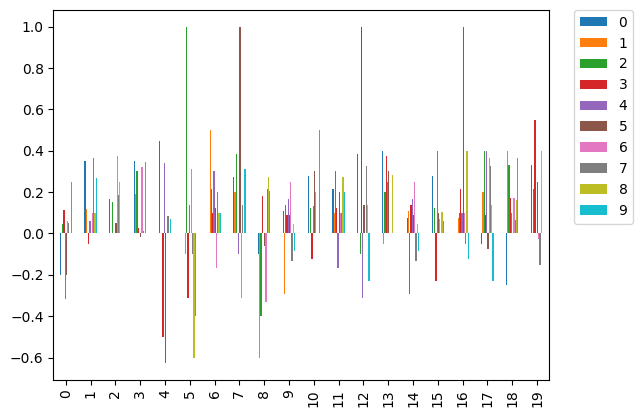

In [ ]:
from textblob import TextBlob
preprocessed_tweets['Sentiment'] = preprocessed_tweets.map(lambda x: TextBlob(x).sentiment.polarity).plot.bar().legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

⬇This code shows the overall polarity of the tweets.

I had difficulty showing the exact polarity of each tweet because the word "Legend" was added to each cell in the "Sentiment" column instead of a number. So, I decided to show overall polarity.

In [ ]:
TextBlob(str(preprocessed_tweets.values)).sentiment.polarity

0.11903390005568423

Polarity goes from -1.0 to 1.0.

Overall polarity was low at 0.119, so the tweets are barely positive, likely neutral. The plotted results seem to show more on the positive side though, with most tweets not going over 0.4. There were also quite a few tweets on the negative side of the plot, so the neutral, barely positive polarity makes sense.

### Word Cloud
I used the WordCloud library to see what the most used words in my pulled tweets are.

There are 3 versions I made: no mentions, with mentions, and the word "privacy" removed. Each version was based on the 200 cleaned tweets from preprocessing, max_words set to 100, and the background_color set to azure. I would've liked to change the the colors used for the words, but ran out of time.

After running the sentiment analysis code, `<matplotlib.legend.Legend object at [hex code]>` was added to each row in the dataframe, so I removed it using the regex library. Before removing that line, parts of it would show in the word cloud. A large part of my time was spent researching how to remove the line added during sentiment analysis. Ulimately, I simply removed it from the word clouds and left the sentiment analysis alone.

⬇ This is the word cloud without mentions. The colors used for some words here are easier to read than in the word cloud with mentions.

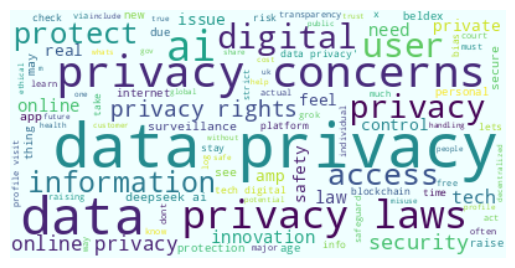

In [ ]:
all_tweets = re.sub(r'<matplotlib.*>', '', str(preprocessed_tweets.values))

all_tweets_cloud = WordCloud(background_color='azure', max_words=100).generate(all_tweets)

plt.imshow(all_tweets_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

⬇ This is the word cloud with mentions. Surprisingly, this doesn't seem much different than the word cloud without mentions. Both display product and entity names clearly. The main difference visually is this word cloud uses more yellow, which has a lower contrast than the blues, greens and purples in the no mentions word cloud.

Companies and products:
- deepseek ai
- grok
- beldex
- x

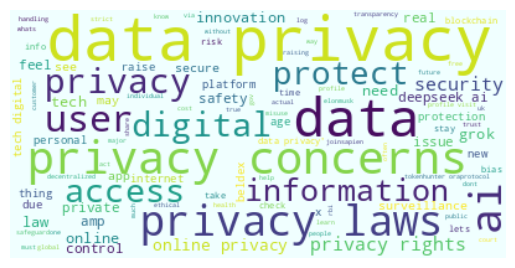

In [ ]:
all_tweets2 = re.sub(r'<matplotlib.*>', '', str(preprocessed_tweets2.values))

all_tweets_cloud2 = WordCloud(background_color='azure', max_words=100).generate(all_tweets2)

plt.imshow(all_tweets_cloud2, interpolation='bilinear')
plt.axis("off")
plt.show()

⬇ This is a word cloud with mentions and the word "privacy" removed. I feel this provides the clearest view of topics discussed compared to the previously created word clouds. Not having the same word show up repeatedly in the word cloud helps!

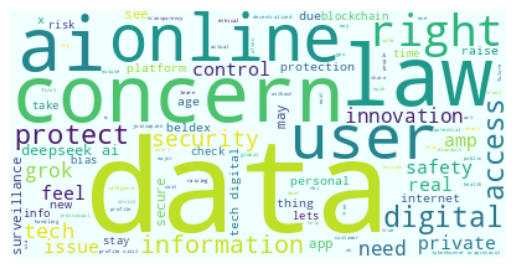

In [ ]:
word_removed = re.sub(r'privacy', '', str(preprocessed_tweets2.values))

common_words_cloud = WordCloud(background_color='azure', max_words=100).generate(word_removed)

plt.imshow(common_words_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

**Top 5 words:**
1. data
2. law
3. ai
4. concern
5. online

From the words I can read, the overall feeling I get is "concern". Some of the other words are also in line with advertising for companies that emphasize security. In addition, the visible words are in line with the overall neutral sentiment shown in sentiment analysis.

### Compared to dataset

I decided to keep the following columns: "Info On Internet", "Worry About Info", "Privacy Importance", "Anonymity Possible", and "Privacy Laws Effective". These columns seem the most relevant based on my word clouds. If I had more data about the X users who posted the tweets pulled, like ages, devices used, and gender, I could use the other columns.

**Summary of whole dataset**

In [ ]:
ds = pd.read_csv('AnonymityPoll.csv')
ds.describe()

,Internet.Use,Smartphone,Age,Conservativeness,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Tried.Masking.Identity,Privacy.Laws.Effective
count,1001.000000,959.000000,975.000000,940.000000,792.000000,790.000000,787.000000,753.000000,784.000000,894.000000
mean,0.774226,0.507821,52.370256,3.276596,3.795455,0.488608,62.848672,0.369190,0.163265,0.261745
std,0.418300,0.500200,18.597082,1.012218,2.699174,0.500187,31.472764,0.482906,0.369844,0.439831
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,37.000000,3.000000,2.000000,0.000000,41.428571,0.000000,0.000000,0.000000
50%,1.000000,1.000000,55.000000,3.000000,4.000000,0.000000,68.750000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,66.000000,4.000000,6.000000,1.000000,88.888889,1.000000,0.000000,1.000000
max,1.000000,1.000000,96.000000,5.000000,11.000000,1.000000,100.000000,1.000000,1.000000,1.000000


**Relevant columns**

About the relevant columns (copied from Kaggle with slight edits by me):

- Info.On.Internet: Number of the 11 items interviewees marked that they were worried about.

- Worry.About.Info: A binary variable indicating if the interviewee worries about how much information is available about them on the Internet (equals 1 if they worry, and equals 0 if they don't worry).

- Privacy.Importance: A score from 0 (privacy is not too important) to 100 (privacy is very important), which combines the degree to which they find privacy important across 9 statements.

- Anonymity.Possible: A binary variable indicating if the interviewee thinks it's possible to use the Internet anonymously, meaning in such a way that online activities can't be traced back to them (equals 1 if he/she believes you can, and equals 0 if he/she believes you can't).

- Privacy.Laws.Effective: A binary variable indicating if the interviewee believes United States law provides reasonable privacy protection for Internet users (equals 1 if he/she believes it does, and equals 0 if he/she believes it doesn't).

In [ ]:
drop_these = [0,1,2,3,4,5,6,11]
ds_to_compare = ds.drop(ds.columns[drop_these], axis=1)
ds_to_compare.describe()

,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Privacy.Laws.Effective
count,792.000000,790.000000,787.000000,753.000000,894.000000
mean,3.795455,0.488608,62.848672,0.369190,0.261745
std,2.699174,0.500187,31.472764,0.482906,0.439831
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,41.428571,0.000000,0.000000
50%,4.000000,0.000000,68.750000,0.000000,0.000000
75%,6.000000,1.000000,88.888889,1.000000,1.000000
max,11.000000,1.000000,100.000000,1.000000,1.000000


**My thoughts on each column**

- "Info.On.Internet" would likely be higher today with all the data leaks that have happened since this poll in 2013. In fact, the week I pulled my tweets, the Tea app "data leak" happened.
- The "Worry About Info" column seems lower than I expected. This matches with the low value of the previous column, though.
- Looking back at my sentiment analysis and word clouds, "Privacy Importance" might not be much different from today. The median is higher than the mean at 68.75, and the standard deviation is 31.47. So, while privacy has stayed on the public's mind, it's not a top concern, but it is a big concern.
- "Anonymity Possible" may acutally be lower today. The week I pulled my tweets, the UK passed requiring ID verification to some sites and some states in the US require it too. Also, social media has shifted to being connected to one's actual name, with some actually requiring it, like FaceBook or LinkedIn. Some of my word cloud words support this, like surveillance, access, and user.
- "Privacy Laws Effective" is low, so it likely still matches with today. Given the rise of AI and numerous data leaks, there's even a possibility of it being lower.

# Conclusion

## Were my questions answered?

Of my 5 questions, 3 were answered:
- How do people feel about digital privacy? And how does it compare to the past?
   - People feel neutral about privacy, mostly leaning towards the positive side.
   - Emotional analysis would provide better insight since it could attach an emotion instead of just positive or negative.
   - Word clouds helped to infer about emotions, but was only my inference, not anything measurable.
   - Without a comparable dataset, it's hard to say how the 2013 dataset compares to today. It's likely that the US public feels mostly the same about digital privacy. On the other hand, it's also possible that people in the US are at least a little more concerned given the numerous data leaks and privacy impacting legislation in the past decade.
     - My Kaggle dataset only contained data about people in the USA, so I do not have the data to compare past and present with other countries.
- What are people talking about?
   - The word clouds helped to provide a general overview of the topics.
   - More specific topics may require a search for most used non-dictionary words.
   - Topic modeling would also be useful.
   - In any case, more ways to go through the pulled tweets and display the results.
- What events are going on regarding privacy?
   - Similar to the previous question, a different or more fine-tuned approach is needed to answer this.
   - Perhaps looking at most used hashtags?
- What is the state of internet privacy outside the US?
   - This question required information about location for each tweet, which I did not have with my pulled tweets. Including fields and expansions in my tweet pulling function would solve this.
- What kinds of businesses are working with privacy in mind?
   - I partially answered this with the word clouds.
   - Deepseek AI, Grok, Beldex, and X displayed prominently in the word clouds. The first 2 are AI, Beldex is a crytocurrency, and X is social media.
   - Interestingly, I saw Elon Musk in the word cloud that included mentions.

## Challenges

TweetLens is my first taste of data science outside of the introductory class I took this past Spring. Each challenge I faced with the code was a journey into research and testing solutions. Finding solutions at the end of each journey was only part of the fun: the journey itself is a joy to partake in. And there were _many_ journeys taken!

A promient challenge throughout was getting used to Pandas and dataframes. In my intro class, we used the datascience library created by UC Berkeley. This library was based on Pandas, so the concepts weren't entirely foreign, just different. I looked up many resources to help me understand dataframes and how to work with them. My process of researching and testing my found solutions formed the base of how I approached each challenge in this project.

The next big challenge was overcoming the rate limit of the free tier of X developer accounts. Before receiving a "Too Many Requests" error, I had different errors, so it was a few days before I realized I was hitting the rate limit. Troubleshooting around the 15 minute rate limit was tedious, especially since I take a trial and error approach. Researching the error after seeing it repeatedly is when I finally realized it was the rate limit stopping me. Thankfully, I was able to adapt my first successful query into a function.

After pulling and saving tweets, learning to use tweet-preprocessor was another challenge. The `.clean_file()` method did not accept CSV files, so I spent a while converting into JSON and TXT files, then feeding those files into the method. Each format was a different problem. Converting into JSON deleted the tweets and converting to TXT changed how the tweets were organized. Ultimately, I opted to use `.clean()` on a dataframe with the tweets since this method worked well in initial testing on single tweets.

The last major coding challenge was sentiment analysis. While I struggled with my tweets dataframe before, this is what really prompted me to reorganize my tweets. The plotted results showed how unevenly distributed the tweets were per row and the legend was twice as tall as the graph! In addition, the legend displayed right in the middle of the graph, hiding some results. After fixing my CSV file, the data was properly distributed in the graph. To fix the legend in the middle, I checked the Pandas documentation which led me to the matplotlib documentation. This part really fascinated me, since data visualization was actually touched upon in the last year of my art degree classes!

The sentiment analysis code brought another problem: `<matplotlib.legend.Legend object at [hex code]>` was appended to the end of each row. (The hex code changed everytime I ran the code.) When using `.describe()` on the plotted results, I was expecting to see the most used word and its frequency. Instead, I saw pieces of the appended line depending on what fix I tried. This became a problem for the word clouds, but was easily fixed there with the re library. Trying the same thing with sentiment analysis, however, undid the adjustments I made to the legend. So, I decided not to include the `.describe()`. In addition to a line of code being appended to each row, the word "Legend" was added to a "Sentiment" column. I expected the polarity of each tweet or row to be added, and could not find an adequete solution to this in time. I think it's because I had multiple columns instead of just one column.

Outside of coding, some personal challenges also arose. Communication is a lifelong challenge of mine, but I did make some minor improvements during the weekly meetings. At first, I felt awkward with the webcam turned on, but with each meeting I felt less awkward until I was finally able to keep it on the whole time. I also slowly built up the courage to ask questions when I was confused during meetings. My biggest struggle that I need to work on is asking for help with my code. I'll research and try as much I can on my own, but this is not efficient time-wise. I need to ask for help sooner! This one thing would have hepled the above challenges resolve faster. 😅 I also need to practice coding more frequently.

## Ending thoughts

With more advanced techniques, I could look deeper into my data and have more solid results. For this project, emotional analysis and topic modeling would help reveal public sentiment and what is going on around the world. Also, a review of data science fundamentals will help when I get stuck or lost.

I enjoyed this project and will consider continuing with data science and analysis in the future. This project has helped me prepare for not only my upcoming classes in the Fall semester, but also for remote work opportunities in the future.

# Thank you for reading!